In [12]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter
from scipy.ndimage import gaussian_filter
from scipy.signal import hilbert
from scipy.ndimage import laplace

275.0
(101, 101)


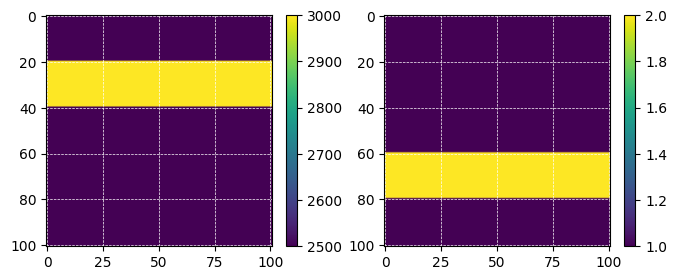

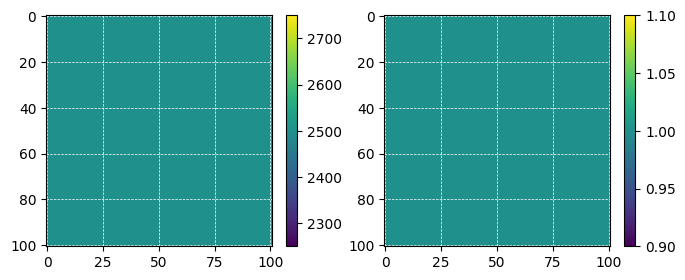

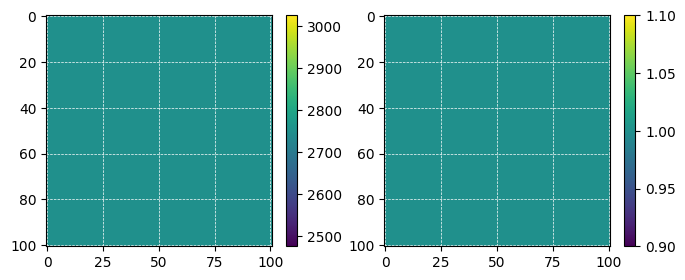

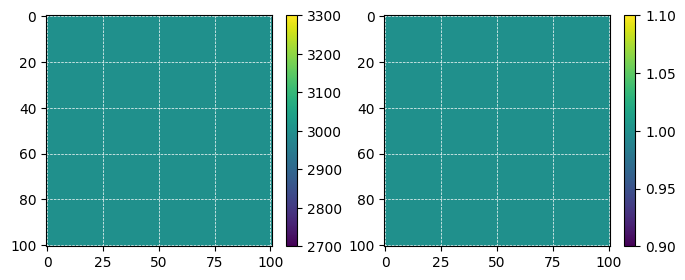

In [4]:
nz=101; nx=101
h=20  #500/20=25

vmin=2500; vmax=3000

nsnap=51; nzsnap=124; nxsnap=124

#5h=lambda=vmin/fmax
fmax=vmin/(5*h) #
fpeak=fmax/2.5  #10 Hz

avg_lambda = (vmin+vmax)/2/(fmax/2.5)
print(avg_lambda)

#on time
dt=0.004
nt=500

ntr=100

#make model
vp=vmin*np.ones((nz,nx)); print(vp.shape)
vp[20:40,:]=vmax
vp.T.astype('float32').tofile('vp')

rho=np.ones((nz,nx))
rho[60:80,:]=2.
rho.T.astype('float32').tofile('rho')

!cat vp rho > true

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('true',(2*nx,nz))[:,:nx])
plt.subplot(1,2,2); imshow(read('true',(2*nx,nz))[:,nx:])

#make model
vp=vmin*np.ones((nz,nx))
vp.T.astype('float32').tofile('vp')

rho=np.ones((nz,nx))
rho.T.astype('float32').tofile('rho')

!cat vp rho > homo

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('homo',(2*nx,nz))[:,:nx])
plt.subplot(1,2,2); imshow(read('homo',(2*nx,nz))[:,nx:])

#make model
vp=(vmin+vmax)/2*np.ones((nz,nx))
vp.T.astype('float32').tofile('vp')

!cat vp rho > avg

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('avg',(2*nx,nz))[:,:nx])
plt.subplot(1,2,2); imshow(read('avg',(2*nx,nz))[:,nx:])

#make model
vp=vmax*np.ones((nz,nx))
vp.T.astype('float32').tofile('vp')

!cat vp rho > wrong

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('wrong',(2*nx,nz))[:,:nx])
plt.subplot(1,2,2); imshow(read('wrong',(2*nx,nz))[:,nx:])

In [5]:
def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=26):
    tmp=np.fromfile(filename,dtype='float32').reshape(n).T
    return tmp[:,:,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/RTM',setup='setup',np=1,nthreads=8,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

In [5]:
!cat setup_default

MODEL_SIZE              '101 101 1'
MODEL_SPACING            '20 20 1'
FILE_MODEL              'true'
MODEL_ATTRIBUTES        'vp rho'
FILE_TOPO               'topo'

IS_FREESURFACE          F

ACQUI_GEOMETRY          spread
FS                      '20  20 0'
FR                      '20  20 0'
DR                      '0   20  0'
NR                      100

IF_HICKS                F

SCOMP                   p
RCOMP                   p #'p vz'

NT               500
DT               0.004


FPEAK            10
WAVELET_TYPE        'ricker'


#SNAPSHOT      'p'


## for RTM ##
FILE_DATA_PREFIX    'results_obs/Ru_Shot'
RTM_ADJSRC          'dres'
WEIGHTING            none
CIG_X         200

JOB           imaging

IF_USE_CHECKPOINT   F



## data

In [28]:
!cp setup_default setup
!echo "DIR_OUT     results_obs" >> setup
run(app='../../exe/fwd_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/06_ImageGathers
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 2323456 Jun 26 13:54 ../../exe/fwd_AC_FDSG_O4_
 Git Commit: 3bc2a52
 Git Branch: RTM
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/26/2025
System time: 14:03:01
System timezone: +08:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 0.4

## SOCIG by RTM

### homo vel

In [29]:
!cp setup_default setup
!echo "FILE_MODEL  homo" >> setup
!echo "DIR_OUT     results_homo" >> setup
run(app='../../exe/rtm_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/06_ImageGathers
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 710320 Jun 29 16:49 ../../exe/rtm_AC_FDSG_O4_
 Git Commit: 602c985
 Git Branch: RTM
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/29/2025
System time: 16:50:57
System timezone: +08:00
                        
       WELCOME TO SeisJIMU RTM        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_homo
 Output directory:results_homo/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 0.

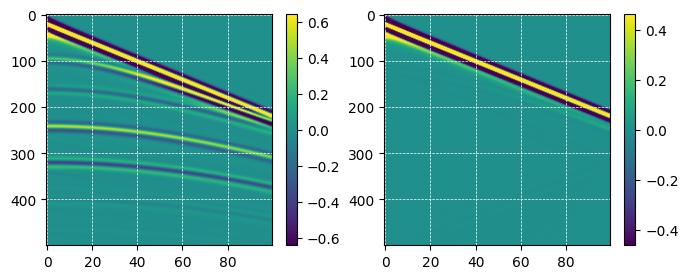

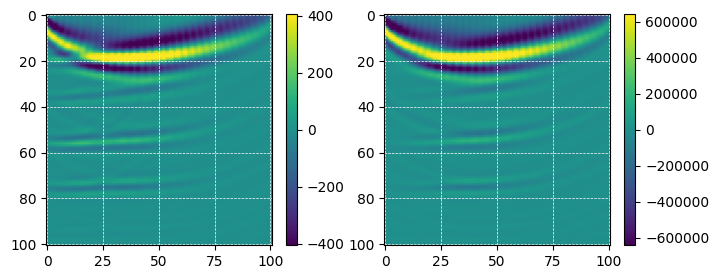

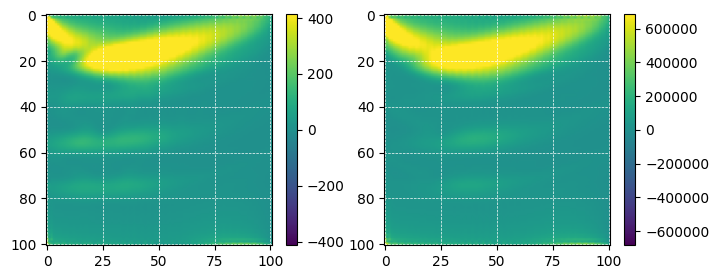

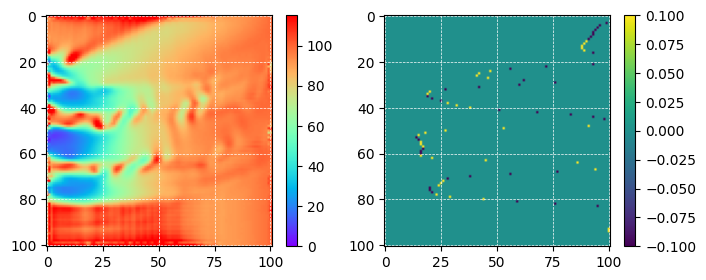

In [30]:
## plot
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read_su('./results_obs/Ru_Shot0001.su') ,perc=95)
plt.subplot(1,2,2); imshow(read_su('./results_homo/Ru_Shot0001.su'),perc=95)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('results_homo/a_star_u%ipp'),perc=98)
plt.subplot(1,2,2); imshow(read('results_homo/a2_star_u%ipp'),perc=98)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('results_homo/imag1'),perc=95)
plt.subplot(1,2,2); imshow(read('results_homo/imag2'),perc=95)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(np.abs(read('results_homo/offset_map'))/h,perc=98,clipmin=0,cmap='rainbow')
plt.subplot(1,2,2); imshow(read('results_homo/CIGs'),perc=98)

### lateral stack to mimic multi-shot case

In [31]:
RTMimage  = read('results_homo/a_star_u%ipp')
ATTRimage = read('results_homo/a2_star_u%ipp')

imag1=read('results_homo/imag1'); thres1=1e-6*np.max(imag1)
imag2=read('results_homo/imag2'); thres2=1e-6*np.max(imag2)

offset_map = np.abs( read('results_homo/offset_map') )
CIGs_stack = np.zeros((nz,101))

for ix in range(nx):
    for iz in range(nz):
        if imag1[iz,ix]>thres1  and  imag2[iz,ix]>thres2:
            ih = round(np.abs(offset_map[iz,ix])/h)
            # print(iz,ix,ih)
            if ih<101:
                CIGs_stack[iz,ih] += RTMimage[iz,ix]

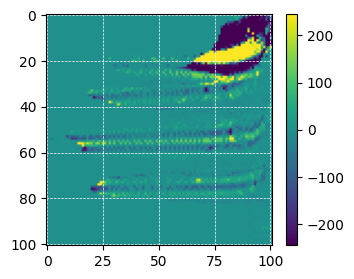

In [32]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(CIGs_stack,perc=95)

### test

In [7]:
from scipy.ndimage import laplace

RTMimage  = -laplace(read('results_homo/a_star_u%ipp'))
ATTRimage = -laplace(read('results_homo/a2_star_u%ipp'))

imag1=hilbert(RTMimage,axis=0)
imag2=hilbert(ATTRimage,axis=0)

#offset_map=read('results_homo/offset_map')
offset_map=np.zeros_like(imag1)
# # update
# for ix in range(nx-5):
#     for iz in range(nz-3):
#         nom   = np.sum(imag2[iz:iz+3,ix:ix+5] * np.conj(imag1[iz:iz+3,ix:ix+5])) #+1e-5
#         denom = np.sum(imag1[iz:iz+3,ix:ix+5] * np.conj(imag1[iz:iz+3,ix:ix+5])) #+1e-5        
#         offset_map[iz,ix] = nom/denom #-1e5

water=np.sum(imag1*np.conj(imag1))*1e-5
offset_map = imag2*np.conj(imag1) /  (imag1*np.conj(imag1)+water)

ioffset_map = np.round( np.real(offset_map) / h )

CIGs_stack = np.zeros((nz,101))

for ix in range(nx):
    for iz in range(nz):
        # if imag1[iz,ix]>thres1  and  imag2[iz,ix]>thres2:
            # print(iz,ix,ih)
            ioff = int(ioffset_map[iz,ix])
            if 0<=ioff and ioff<101:
                CIGs_stack[iz,ioff] += RTMimage[iz,ix]

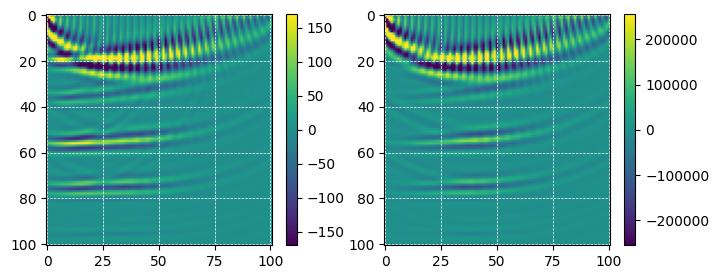

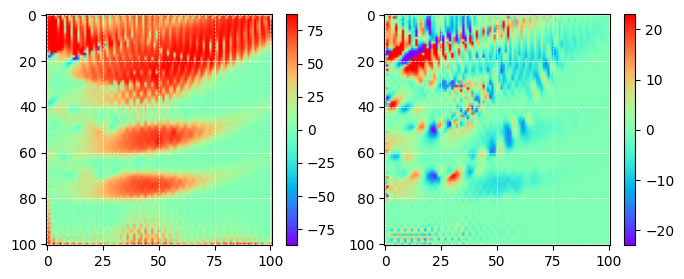

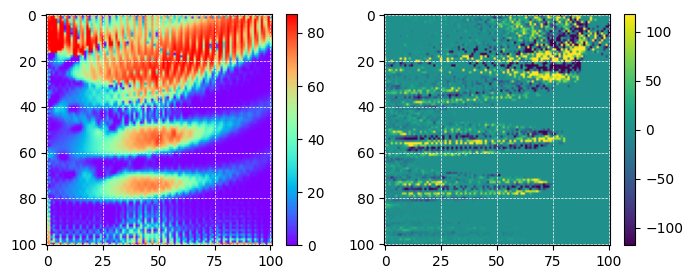

In [39]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(RTMimage,perc=98)
plt.subplot(1,2,2); imshow(ATTRimage,perc=98)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(np.real(offset_map)/h,perc=98,cmap='rainbow')
plt.subplot(1,2,2); imshow(np.imag(offset_map)/h,perc=98,cmap='rainbow')

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(ioffset_map,perc=98,clipmin=0,cmap='rainbow')
plt.subplot(1,2,2); imshow(CIGs_stack,perc=95)

(-1000000.0, 1000000.0)

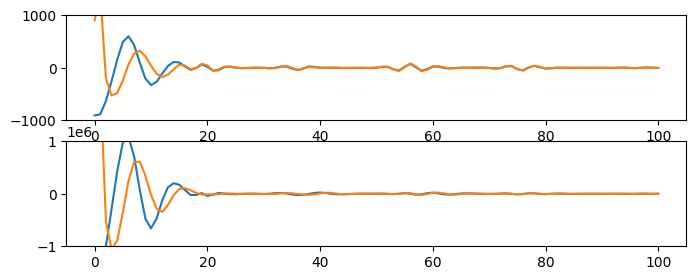

In [35]:
plt.figure(figsize=(8,3))
plt.subplot(2,1,1); plt.plot(RTMimage [:,0]); plt.plot(RTMimage [:,1]); plt.ylim([-1e3,1e3])
plt.subplot(2,1,2); plt.plot(ATTRimage[:,0]); plt.plot(ATTRimage[:,1]); plt.ylim([-1e6,1e6])

### test2

In [41]:
from scipy.ndimage import laplace

RTMimage  = -laplace(read('results_homo/a_star_u%ipp'))
ATTRimage = -laplace(read('results_homo/a2_star_u%ipp'))

imag1=hilbert(RTMimage,axis=0)
imag2=hilbert(ATTRimage,axis=0)

#offset_map=read('results_homo/offset_map')
offset_map=np.zeros_like(imag1)
# update
for ix in range(nx-5):
    for iz in range(nz-3):
        nom   = np.sum(imag2[iz:iz+3,ix:ix+5] * np.conj(imag1[iz:iz+3,ix:ix+5])) #+1e-5
        denom = np.sum(imag1[iz:iz+3,ix:ix+5] * np.conj(imag1[iz:iz+3,ix:ix+5])) #+1e-5        
        offset_map[iz,ix] = nom/(denom+1e-5)

ioffset_map = np.round( np.real(offset_map) / h )

CIGs_stack = np.zeros((nz,101))

for ix in range(nx):
    for iz in range(nz):
        ioff = int(ioffset_map[iz,ix])
        if 0<=ioff and ioff<101:
            CIGs_stack[iz,ioff] += RTMimage[iz,ix]

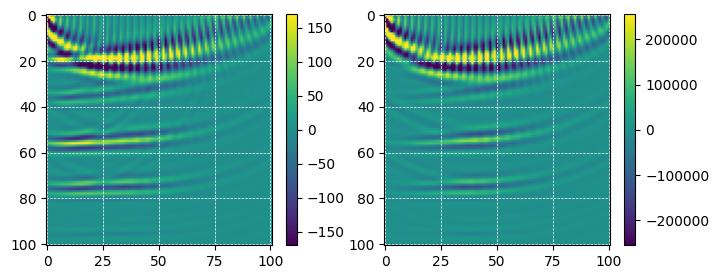

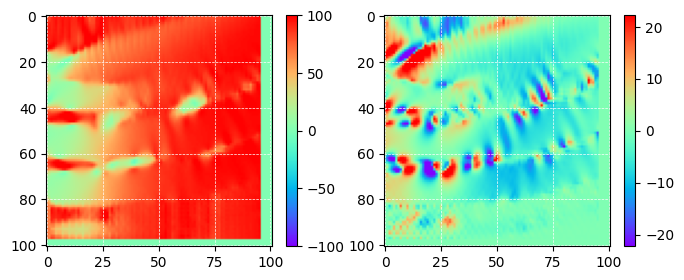

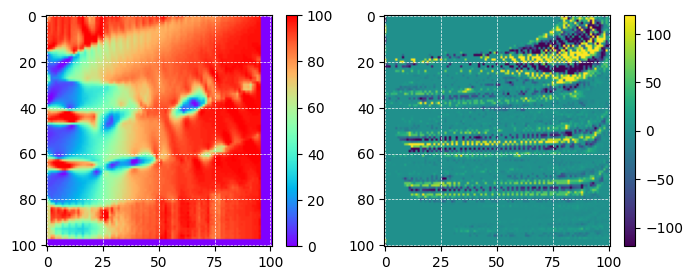

In [43]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(RTMimage,perc=98)
plt.subplot(1,2,2); imshow(ATTRimage,perc=98)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(np.real(offset_map)/h,perc=98,cmap='rainbow')
plt.subplot(1,2,2); imshow(np.imag(offset_map)/h,perc=98,cmap='rainbow')

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(ioffset_map,perc=98,clipmin=0,cmap='rainbow')
plt.subplot(1,2,2); imshow(CIGs_stack,perc=95)

(-1000000.0, 1000000.0)

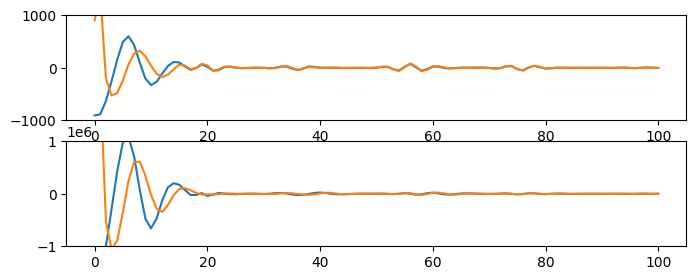

In [44]:
plt.figure(figsize=(8,3))
plt.subplot(2,1,1); plt.plot(RTMimage [:,0]); plt.plot(RTMimage [:,1]); plt.ylim([-1e3,1e3])
plt.subplot(2,1,2); plt.plot(ATTRimage[:,0]); plt.plot(ATTRimage[:,1]); plt.ylim([-1e6,1e6])

### test3

In [45]:
RTMimage  = -laplace(read('results_homo/a_star_u%ipp'))
ATTRimage = -laplace(read('results_homo/a2_star_u%ipp'))

imag1=hilbert(RTMimage,axis=0)
imag2=hilbert(ATTRimage,axis=0)

#offset_map=read('results_homo/offset_map')
offset_map=np.zeros_like(imag1)
# # update
# for ix in range(nx-5):
#     for iz in range(nz-3):
#         nom   = np.sum(imag2[iz:iz+3,ix:ix+5] * np.conj(imag1[iz:iz+3,ix:ix+5])) #+1e-5
#         denom = np.sum(imag1[iz:iz+3,ix:ix+5] * np.conj(imag1[iz:iz+3,ix:ix+5])) #+1e-5        
#         offset_map[iz,ix] = nom/denom #-1e5

water=np.sum(imag1*np.conj(imag1))*1e-5
offset_map = imag2*np.conj(imag1) /  (imag1*np.conj(imag1)+water)

ioffset_map = np.round( np.real(offset_map) / h )

In [47]:
# def gen_CIG(offset_map,dh=h):
#     CIGs_stack = np.zeros((nz,101))
    
#     for ix in range(nx):
#         for iz in range(nz):
#             # if imag1[iz,ix]>thres1  and  imag2[iz,ix]>thres2:
#                 ih = round(np.abs(offset_map[iz,ix])/dh)
#                 if ih<101:
#                     CIGs_stack[iz,ih] += RTMimage[iz,ix]
    
#     return CIGs_stack

def gen_CIG(ioffset_map):
    CIGs_stack = np.zeros((nz,101))
    
    for ioff in range(101):
        for iz in range(nz):
            # if imag1[iz,ix]>thres1  and  imag2[iz,ix]>thres2:
            for ix in range(nx):
                if np.abs(ioff - ioffset_map[iz,ix]) <= 2 :
                    CIGs_stack[iz,ioff] += RTMimage[iz,ix]
    
    return CIGs_stack
    

n1=101 n2=101 d1=0.000000
nt=101 ntr=101 dt=0.000000
ns=101


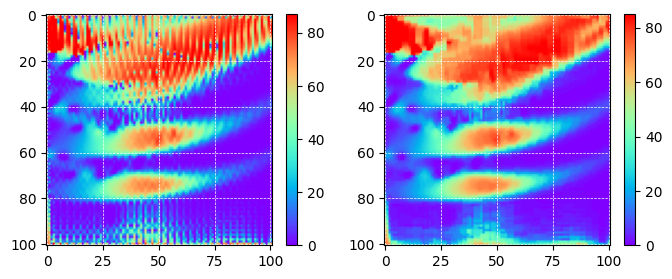

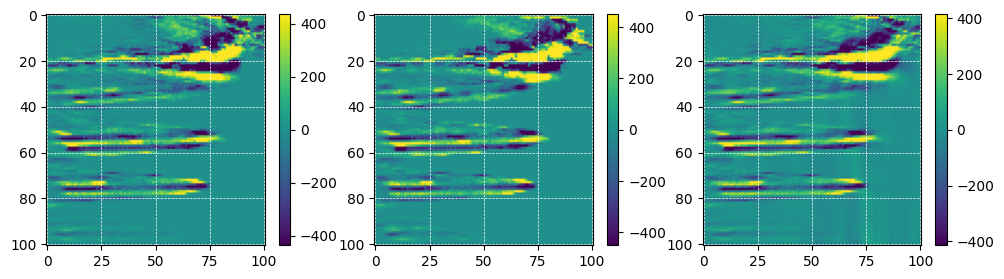

In [48]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(ioffset_map,perc=98,clipmin=0,cmap='rainbow')

ioffset_map_proc = median_filter(ioffset_map,size=(3,3),mode='nearest')
plt.subplot(1,2,2); imshow(ioffset_map_proc,perc=98,clipmin=0,cmap='rainbow')

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(gen_CIG(ioffset_map),perc=95)
plt.subplot(1,3,2); imshow(gen_CIG(ioffset_map_proc),perc=95)

CIGs_stack=gen_CIG(ioffset_map)
CIGs_stack.T.astype('float32').tofile('CIGs_stack')
!suaddhead < CIGs_stack ns=101 > CIGs_stack.su
!sudipfilt < CIGs_stack.su   dt=1 dx=1  slopes=-50,-40,0,1 amps=0,1,1,0 | sustrip > CIGs_stack_filt

plt.subplot(1,3,3); imshow(read('CIGs_stack_filt',(101,101)),perc=95)

In [49]:
def gen_CIG_wavelet(ioffset_map):
    CIGs_stack = np.zeros((nz,101))
    
    for ioff in range(101):
        for iz in range(3,nz-3):
            for ix in range(nx):
                if np.abs(ioff - ioffset_map[iz,ix]) <= 3 :
                    CIGs_stack[iz-3:iz+3,ioff] += RTMimage[iz-3:iz+3,ix]
    
    return CIGs_stack

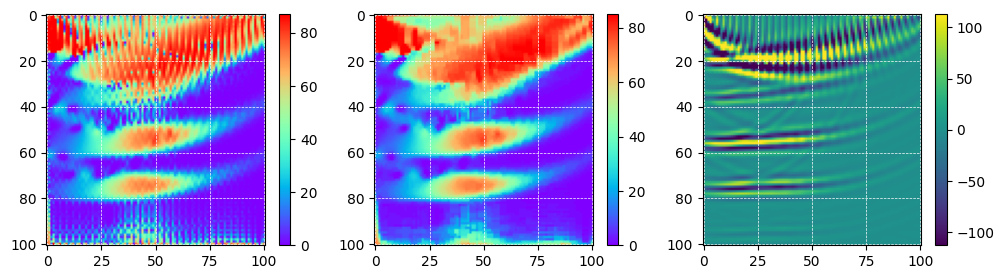

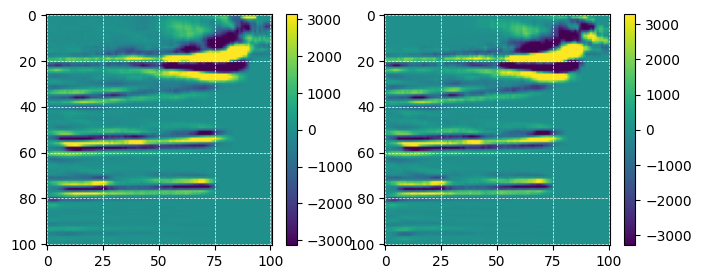

In [52]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(ioffset_map,perc=98,clipmin=0,cmap='rainbow')

ioffset_map_proc = median_filter(ioffset_map,size=(3,3),mode='nearest')
plt.subplot(1,3,2); imshow(ioffset_map_proc,perc=98,clipmin=0,cmap='rainbow')

plt.subplot(1,3,3); imshow(RTMimage,perc=95)


plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(gen_CIG_wavelet(ioffset_map),perc=95)
plt.subplot(1,2,2); imshow(gen_CIG_wavelet(ioffset_map_proc),perc=95)

#### **sofar better**

### test4

In [53]:
RTMimage  = -laplace(read('results_homo/a_star_u%ipp'))
ATTRimage = -laplace(read('results_homo/a2_star_u%ipp'))

imag1=hilbert(RTMimage,axis=0)
imag2=hilbert(ATTRimage,axis=0)

#offset_map=read('results_homo/offset_map')
offset_map=np.zeros_like(imag1)
# update
for ix in range(nx-3):
    for iz in range(nz-3):
        nom   = np.sum(imag2[iz:iz+3,ix:ix+3] * np.conj(imag1[iz:iz+3,ix:ix+3])) #+1e-5
        denom = np.sum(imag1[iz:iz+3,ix:ix+3] * np.conj(imag1[iz:iz+3,ix:ix+3])) #+1e-5        
        offset_map[iz,ix] = nom/denom

# water=np.sum(imag1*np.conj(imag1))*1e-5
# offset_map = imag2*np.conj(imag1) /  (imag1*np.conj(imag1)+water)

ioffset_map = np.round( np.real(offset_map) / h )

In [54]:
def gen_CIG(ioffset_map):
    CIGs_stack = np.zeros((nz,101))
    
    for ioff in range(101):
        for iz in range(nz):
            # if imag1[iz,ix]>thres1  and  imag2[iz,ix]>thres2:
            for ix in range(nx):
                if np.abs(ioff - ioffset_map[iz,ix]) <= 2 :
                    CIGs_stack[iz,ioff] += RTMimage[iz,ix]
    
    return CIGs_stack
    

n1=101 n2=101 d1=0.000000
nt=101 ntr=101 dt=0.000000
ns=101


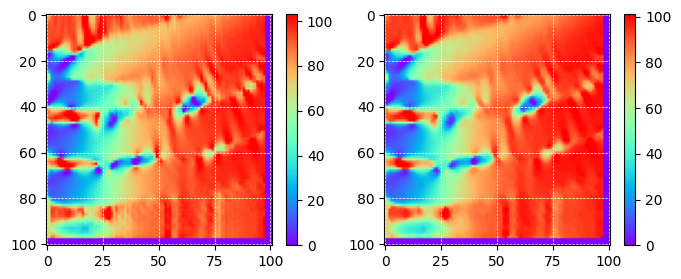

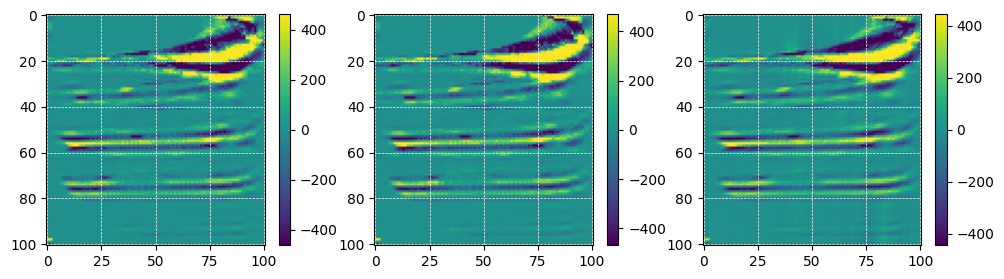

In [55]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(ioffset_map,perc=98,clipmin=0,cmap='rainbow')

ioffset_map_proc = median_filter(ioffset_map,size=(3,3),mode='nearest')
plt.subplot(1,2,2); imshow(ioffset_map_proc,perc=98,clipmin=0,cmap='rainbow')

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(gen_CIG(ioffset_map),perc=95)
plt.subplot(1,3,2); imshow(gen_CIG(ioffset_map_proc),perc=95)

CIGs_stack=gen_CIG(ioffset_map)
CIGs_stack.T.astype('float32').tofile('CIGs_stack')
!suaddhead < CIGs_stack ns=101 > CIGs_stack.su
!sudipfilt < CIGs_stack.su   dt=1 dx=1  slopes=-50,-40,0,1 amps=0,1,1,0 | sustrip > CIGs_stack_filt

plt.subplot(1,3,3); imshow(read('CIGs_stack_filt',(101,101)),perc=95)

In [56]:
def gen_CIG_wavelet(ioffset_map):
    CIGs_stack = np.zeros((nz,101))
    
    for ioff in range(101):
        for iz in range(3,nz-3):
            for ix in range(nx):
                if np.abs(ioff - ioffset_map[iz,ix]) <= 3 :
                    CIGs_stack[iz-3:iz+3,ioff] += RTMimage[iz-3:iz+3,ix]
    
    return CIGs_stack

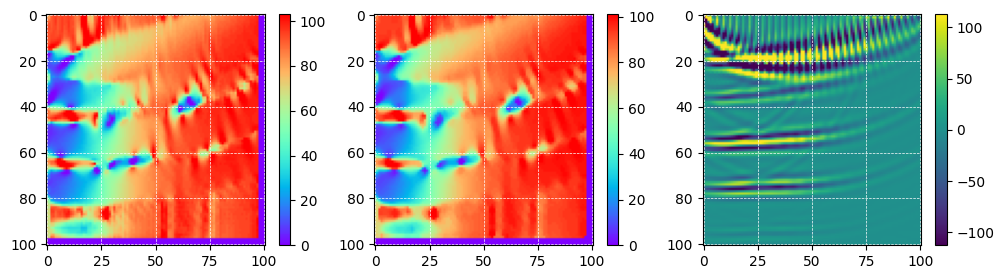

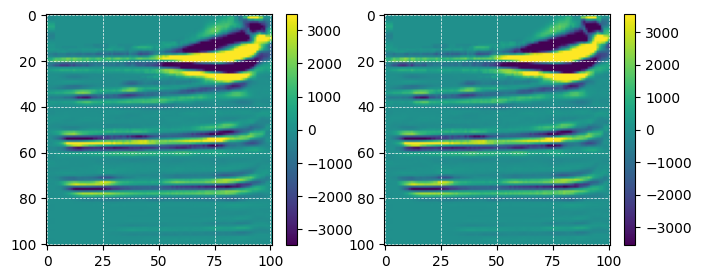

In [57]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(ioffset_map,perc=98,clipmin=0,cmap='rainbow')

ioffset_map_proc = median_filter(ioffset_map,size=(3,3),mode='nearest')
plt.subplot(1,3,2); imshow(ioffset_map_proc,perc=98,clipmin=0,cmap='rainbow')

plt.subplot(1,3,3); imshow(RTMimage,perc=95)


plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(gen_CIG_wavelet(ioffset_map),perc=95)
plt.subplot(1,2,2); imshow(gen_CIG_wavelet(ioffset_map_proc),perc=95)

### test5

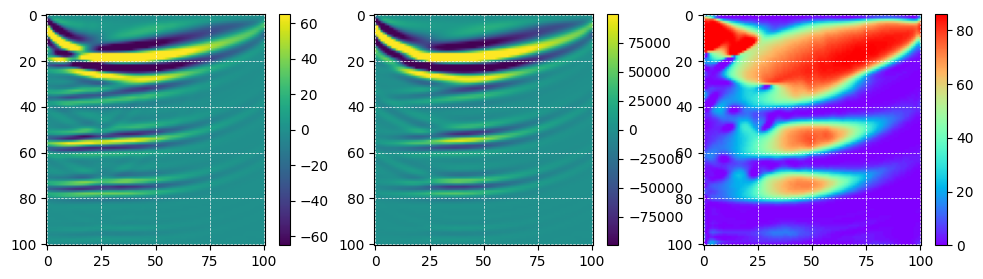

In [28]:
from scipy.signal.windows import hann

RTMimage  = gaussian_filter(-laplace(read('results_homo/a_star_u%ipp' )),sigma=(1,2),mode='nearest')
ATTRimage = gaussian_filter(-laplace(read('results_homo/a2_star_u%ipp')),sigma=(1,2),mode='nearest')

top_wind = hann(11)[:6]
for ix in range(nx):
    RTMimage [:6,ix] *= top_wind
    ATTRimage[:6,ix] *= top_wind

imag1=hilbert( RTMimage , axis=0)
imag2=hilbert( ATTRimage, axis=0)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(RTMimage,perc=95)
plt.subplot(1,3,2); imshow(ATTRimage,perc=95)

#offset_map=read('results_homo/offset_map')
offset_map=np.zeros_like(imag1)
# # update
# for ix in range(nx):
#     for iz in range(nz-3):
#         nom   = np.sum(imag2[iz:iz+3,ix] * np.conj(imag1[iz:iz+3,ix])) #+1e-5
#         denom = np.sum(imag1[iz:iz+3,ix] * np.conj(imag1[iz:iz+3,ix])) #+1e-5        
#         offset_map[iz,ix] = nom/denom #-1e5

water=np.sum(imag1*np.conj(imag1))*1e-5
offset_map = imag2*np.conj(imag1) / (imag1*np.conj(imag1)+water)

ioffset_map = np.round( np.real(offset_map) / h )

plt.subplot(1,3,3); imshow(ioffset_map,perc=98,clipmin=0,cmap='rainbow')

In [29]:
def gen_CIG(ioffset_map):
    CIGs_stack = np.zeros((nz,101))
    
    for ioff in range(101):
        for iz in range(nz):
            # if imag1[iz,ix]>thres1  and  imag2[iz,ix]>thres2:
            for ix in range(nx):
                if np.abs(ioff - ioffset_map[iz,ix]) <= 3 :
                    CIGs_stack[iz,ioff] += RTMimage[iz,ix]
    
    return CIGs_stack

def gen_CIG_wavelet(ioffset_map):
    CIGs_stack = np.zeros((nz,101))
    
    for ioff in range(101):
        for iz in range(3,nz-3):
            for ix in range(nx):
                if np.abs(ioff - ioffset_map[iz,ix]) <= 3 :
                    CIGs_stack[iz-3:iz+3,ioff] += RTMimage[iz-3:iz+3,ix]
    
    return CIGs_stack

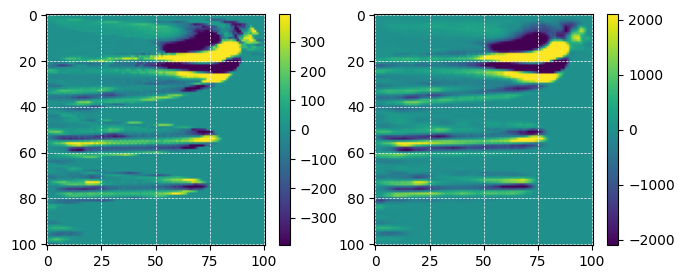

In [30]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(gen_CIG(ioffset_map),perc=95)
plt.subplot(1,3,2); imshow(gen_CIG_wavelet(ioffset_map),perc=95)

#### **sofar best**

### avg vel

In [60]:
!cp setup_default setup
!echo "FILE_MODEL  avg" >> setup
# !echo "WEIGHTING   polygon:mute_dir" >> setup
!echo "DIR_OUT     results_avg" >> setup
# !echo "RTM_ADJSRC     dobs" >> setup
run(app='../../exe/rtm_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/06_ImageGathers
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 710320 Jun 29 16:49 ../../exe/rtm_AC_FDSG_O4_
 Git Commit: 602c985
 Git Branch: RTM
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/29/2025
System time: 23:26:33
System timezone: +08:00
                        
       WELCOME TO SeisJIMU RTM        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_avg
 Output directory:results_avg/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 0.49

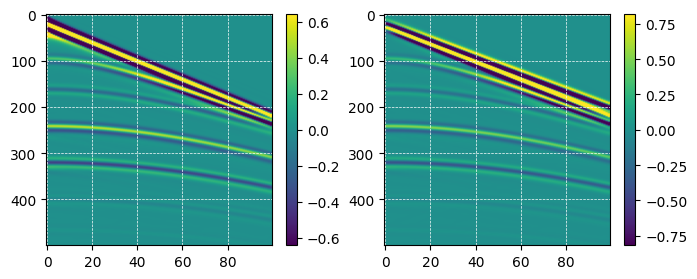

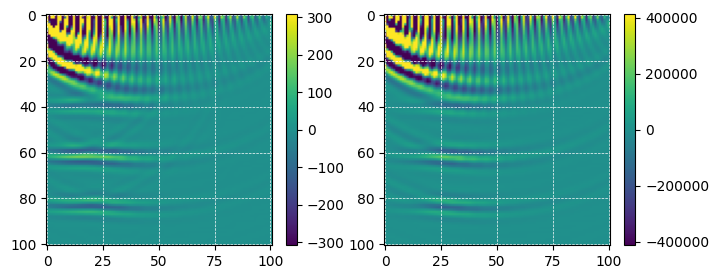

In [61]:
## plot
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read_su('./results_obs/Ru_Shot0001.su') ,perc=95)
plt.subplot(1,2,2); imshow(read_su('./results_avg/dadj_Shot0001.su'),perc=95)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(-laplace(read('results_avg/a_star_u%ipp')),perc=95)
plt.subplot(1,2,2); imshow(-laplace(read('results_avg/a2_star_u%ipp')),perc=95)

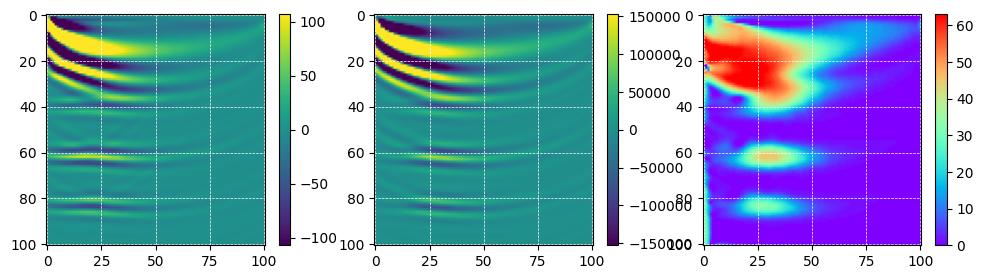

In [62]:
from scipy.signal.windows import hann

RTMimage  = gaussian_filter(-laplace(read('results_avg/a_star_u%ipp' )),sigma=(1,2),mode='nearest')
ATTRimage = gaussian_filter(-laplace(read('results_avg/a2_star_u%ipp')),sigma=(1,2),mode='nearest')

top_wind = hann(11)[:6]
for ix in range(nx):
    RTMimage [:6,ix] *= top_wind
    ATTRimage[:6,ix] *= top_wind

imag1=hilbert( RTMimage , axis=0)
imag2=hilbert( ATTRimage, axis=0)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(RTMimage,perc=95)
plt.subplot(1,3,2); imshow(ATTRimage,perc=95)

#offset_map=read('results_homo/offset_map')
offset_map=np.zeros_like(imag1)
# # update
# for ix in range(nx):
#     for iz in range(nz-3):
#         nom   = np.sum(imag2[iz:iz+3,ix] * np.conj(imag1[iz:iz+3,ix])) #+1e-5
#         denom = np.sum(imag1[iz:iz+3,ix] * np.conj(imag1[iz:iz+3,ix])) #+1e-5        
#         offset_map[iz,ix] = nom/denom #-1e5

water=np.sum(imag1*np.conj(imag1))*1e-5
offset_map = imag2*np.conj(imag1) / (imag1*np.conj(imag1)+water)

ioffset_map = np.round( np.real(offset_map) / h )

plt.subplot(1,3,3); imshow(ioffset_map,perc=98,clipmin=0,cmap='rainbow')

In [63]:
def gen_CIG(ioffset_map):
    CIGs_stack = np.zeros((nz,101))
    
    for ioff in range(101):
        for iz in range(nz):
            # if imag1[iz,ix]>thres1  and  imag2[iz,ix]>thres2:
            for ix in range(nx):
                if np.abs(ioff - ioffset_map[iz,ix]) <= 3 :
                    CIGs_stack[iz,ioff] += RTMimage[iz,ix]
    
    return CIGs_stack

def gen_CIG_wavelet(ioffset_map):
    CIGs_stack = np.zeros((nz,101))
    
    for ioff in range(101):
        for iz in range(3,nz-3):
            for ix in range(nx):
                if np.abs(ioff - ioffset_map[iz,ix]) <= 3 :
                    CIGs_stack[iz-3:iz+3,ioff] += RTMimage[iz-3:iz+3,ix]
    
    return CIGs_stack

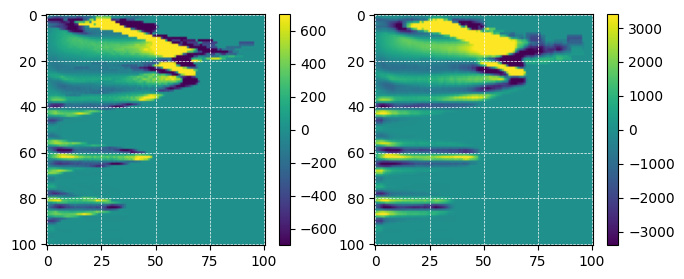

In [64]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(gen_CIG(ioffset_map),perc=95)
plt.subplot(1,3,2); imshow(gen_CIG_wavelet(ioffset_map),perc=95)

### wrong vel

In [51]:
!cp setup_default setup
!echo "FILE_MODEL  wrong" >> setup
# !echo "WEIGHTING   polygon:mute_dir" >> setup
!echo "DIR_OUT     results_wrong" >> setup
!echo "RTM_ADJSRC     dobs" >> setup
run(app='../../exe/rtm_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/06_ImageGathers
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 710320 Jun 29 16:49 ../../exe/rtm_AC_FDSG_O4_
 Git Commit: 602c985
 Git Branch: RTM
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/29/2025
System time: 23:23:36
System timezone: +08:00
                        
       WELCOME TO SeisJIMU RTM        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_wrong
 Output directory:results_wrong/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 

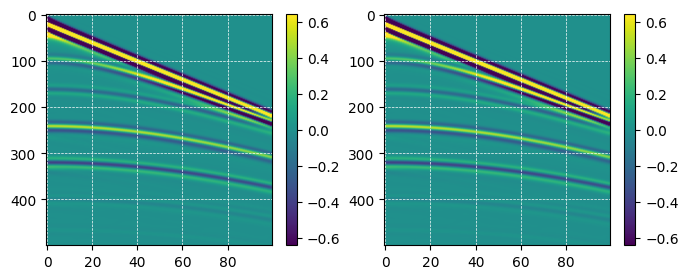

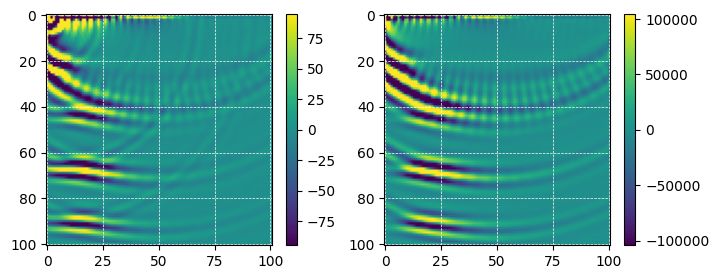

In [52]:
## plot
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read_su('./results_obs/Ru_Shot0001.su') ,perc=95)
plt.subplot(1,2,2); imshow(read_su('./results_wrong/dadj_Shot0001.su'),perc=95)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(-laplace(read('results_wrong/a_star_u%ipp')),perc=95)
plt.subplot(1,2,2); imshow(-laplace(read('results_wrong/a2_star_u%ipp')),perc=95)

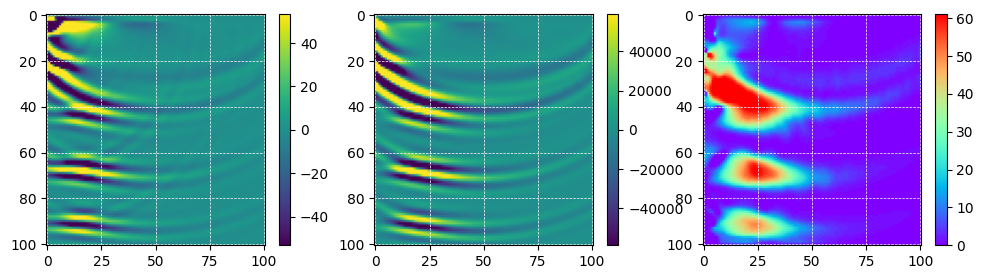

In [54]:
from scipy.signal.windows import hann

RTMimage  = gaussian_filter(-laplace(read('results_wrong/a_star_u%ipp' )),sigma=(1,2),mode='nearest')
ATTRimage = gaussian_filter(-laplace(read('results_wrong/a2_star_u%ipp')),sigma=(1,2),mode='nearest')

top_wind = hann(11)[:6]
for ix in range(nx):
    RTMimage [:6,ix] *= top_wind
    ATTRimage[:6,ix] *= top_wind

imag1=hilbert( RTMimage , axis=0)
imag2=hilbert( ATTRimage, axis=0)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(RTMimage,perc=95)
plt.subplot(1,3,2); imshow(ATTRimage,perc=95)

#offset_map=read('results_homo/offset_map')
offset_map=np.zeros_like(imag1)
# # update
# for ix in range(nx):
#     for iz in range(nz-3):
#         nom   = np.sum(imag2[iz:iz+3,ix] * np.conj(imag1[iz:iz+3,ix])) #+1e-5
#         denom = np.sum(imag1[iz:iz+3,ix] * np.conj(imag1[iz:iz+3,ix])) #+1e-5        
#         offset_map[iz,ix] = nom/denom #-1e5

water=np.sum(imag1*np.conj(imag1))*1e-5
offset_map = imag2*np.conj(imag1) / (imag1*np.conj(imag1)+water)

ioffset_map = np.round( np.real(offset_map) / h )

plt.subplot(1,3,3); imshow(ioffset_map,perc=98,clipmin=0,cmap='rainbow')

In [55]:
def gen_CIG(ioffset_map):
    CIGs_stack = np.zeros((nz,101))
    
    for ioff in range(101):
        for iz in range(nz):
            # if imag1[iz,ix]>thres1  and  imag2[iz,ix]>thres2:
            for ix in range(nx):
                if np.abs(ioff - ioffset_map[iz,ix]) <= 3 :
                    CIGs_stack[iz,ioff] += RTMimage[iz,ix]
    
    return CIGs_stack

def gen_CIG_wavelet(ioffset_map):
    CIGs_stack = np.zeros((nz,101))
    
    for ioff in range(101):
        for iz in range(3,nz-3):
            for ix in range(nx):
                if np.abs(ioff - ioffset_map[iz,ix]) <= 3 :
                    CIGs_stack[iz-3:iz+3,ioff] += RTMimage[iz-3:iz+3,ix]
    
    return CIGs_stack

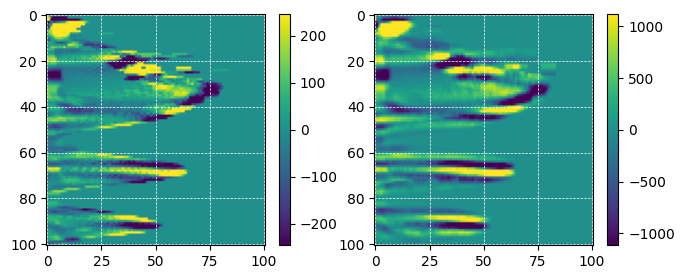

In [56]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(gen_CIG(ioffset_map),perc=95)
plt.subplot(1,3,2); imshow(gen_CIG_wavelet(ioffset_map),perc=95)

## smaller offsets

### homo vel offset

In [31]:
!cp setup_default setup
!echo "FILE_MODEL  homo" >> setup
!echo "FILE_DATA_PREFIX    'results_obs2/Ru_Shot'" >> setup
!echo "DIR_OUT     results_homo2_offset" >> setup
run(app='../../exe/rtm_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/06_ImageGathers
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 710320 Jun 29 16:49 ../../exe/rtm_AC_FDSG_O4_
 Git Commit: 602c985
 Git Branch: RTM
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/29/2025
System time: 23:14:20
System timezone: +08:00
                        
       WELCOME TO SeisJIMU RTM        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_homo2_offset
 Output directory:results_homo2_offset/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.6

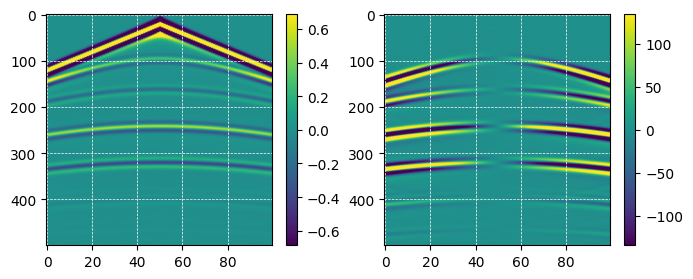

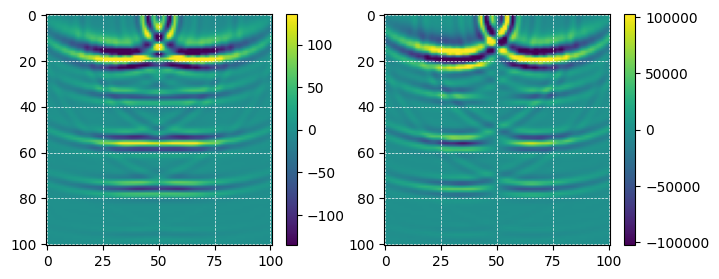

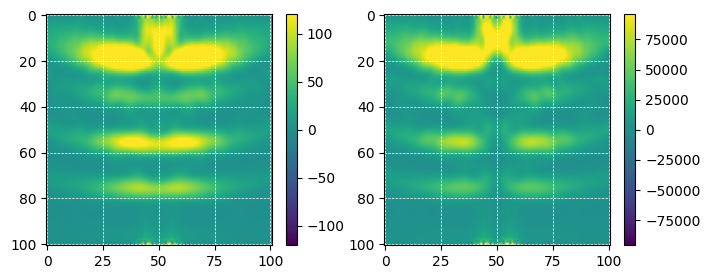

In [79]:
## plot
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read_su('./results_obs2/Ru_Shot0001.su'),perc=95)
plt.subplot(1,2,2); imshow(read_su('./results_homo2_offset/dadj2_Shot0001.su'),perc=95)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('results_homo2_offset/a_star_u%ipp'),perc=98)
plt.subplot(1,2,2); imshow(read('results_homo2_offset/a2_star_u%ipp'),perc=98)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('results_homo2_offset/imag1'),perc=95)
plt.subplot(1,2,2); imshow(read('results_homo2_offset/imag2'),perc=95)

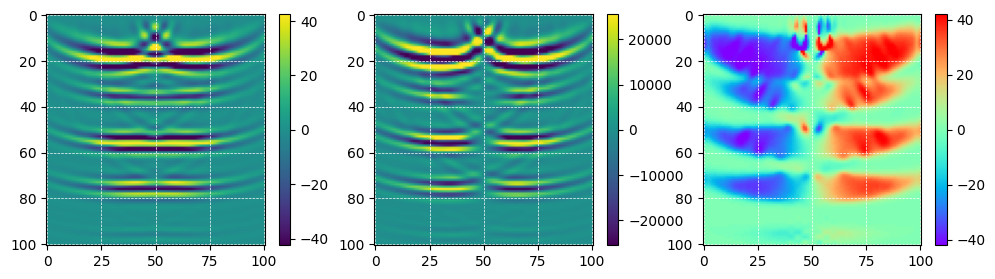

In [34]:
from scipy.signal.windows import hann

RTMimage  = gaussian_filter(-laplace(read('results_homo2_offset/a_star_u%ipp' )),sigma=(1,2),mode='nearest')
ATTRimage = gaussian_filter(-laplace(read('results_homo2_offset/a2_star_u%ipp')),sigma=(1,2),mode='nearest')

top_wind = hann(11)[:6]
for ix in range(nx):
    RTMimage [:6,ix] *= top_wind
    ATTRimage[:6,ix] *= top_wind

imag1=hilbert( RTMimage , axis=0)
imag2=hilbert( ATTRimage, axis=0)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(RTMimage,perc=95)
plt.subplot(1,3,2); imshow(ATTRimage,perc=95)

#offset_map=read('results_homo/offset_map')
offset_map=np.zeros_like(imag1)
# # update
# for ix in range(nx):
#     for iz in range(nz-3):
#         nom   = np.sum(imag2[iz:iz+3,ix] * np.conj(imag1[iz:iz+3,ix])) #+1e-5
#         denom = np.sum(imag1[iz:iz+3,ix] * np.conj(imag1[iz:iz+3,ix])) #+1e-5        
#         offset_map[iz,ix] = nom/denom #-1e5

water=np.sum(imag1*np.conj(imag1))*1e-5
offset_map = imag2*np.conj(imag1) / (imag1*np.conj(imag1)+water)

ioffset_map = np.round( np.real(offset_map) / h )

plt.subplot(1,3,3); imshow(ioffset_map,perc=98,cmap='rainbow')

In [37]:
def gen_CIG(ioffset_map):
    CIGs_stack = np.zeros((nz,101))
    
    for ioff in range(101):
        for iz in range(nz):
            for ix in range(nx):
                if np.abs(ioff-50 - ioffset_map[iz,ix]) <= 3 :
                    CIGs_stack[iz,ioff] += RTMimage[iz,ix]
    
    return CIGs_stack

def gen_CIG_wavelet(ioffset_map):
    CIGs_stack = np.zeros((nz,101))
    
    for ioff in range(101):
        for iz in range(3,nz-3):
            for ix in range(nx):
                if np.abs(ioff-50 - ioffset_map[iz,ix]) <= 3 :
                    CIGs_stack[iz-3:iz+3,ioff] += RTMimage[iz-3:iz+3,ix]
    
    return CIGs_stack

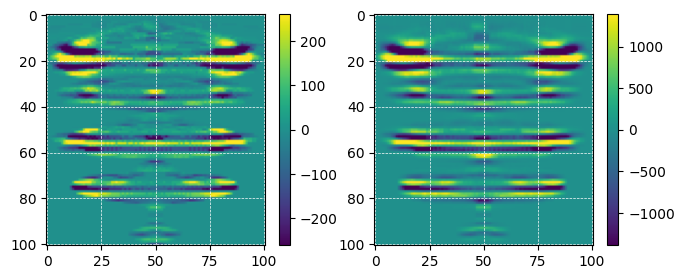

In [38]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(gen_CIG(ioffset_map),perc=95)
plt.subplot(1,3,2); imshow(gen_CIG_wavelet(ioffset_map),perc=95)